# 🧠 Módulo 06: Post-Training, Fine-Tuning y el Arte del LLM
## Capítulo 4: Razonamiento, Cadenas de Pensamiento (CoT) y Cómputo en Tiempo de Inferencia (Test-Time Compute)

> *"Durante años, la ley de escalado de la IA parecía depender únicamente del cómputo de pre-entrenamiento (más GPUs, más datos, modelos más grandes). Con la llegada de Chain-of-Thought (Wei et al., 2022), Tree of Thoughts (Yao et al., 2023) y modelos como OpenAI o1 y DeepSeek-R1 (2024/2025), el paradigma cambió para siempre: un modelo pequeño puede superar a un modelo gigante si se le permite 'pensar más tiempo' en inferencia. Al descomponer un problema en pasos lógicos intermedios y explorar árboles de búsqueda (Best-of-N, Beam Search, MCTS), el cómputo en tiempo de prueba (*test-time compute*) transforma la predicción autorregresiva en auténtica deducción algorítmica."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/06_post_training/04_reasoning_and_test_time_compute.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict, Optional, Any
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar Razonamiento, CoT y Test-Time Compute from scratch")

✅ Entorno listo para estudiar Razonamiento, CoT y Test-Time Compute from scratch


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### El Cuello de Botella Computacional de la Inferencia Directa (2020 - 2022)
En un Transformer estándar, la cantidad de operaciones en coma flotante (FLOPs) por token generado es **estrictamente constante e idéntica** ($O(1)$ capas por token):
* Si le pides al modelo: *"¿Cuánto es 2 + 2?"*, consume el mismo cómputo que si le pides: *"Demuestra el Último Teorema de Fermat"*.
* Exigir a un modelo responder a una pregunta lógica o matemática compleja en un solo paso equivale a pedirle a un algoritmo de ordenación $O(N \log N)$ que ordene un arreglo en un solo ciclo de CPU: **es computacionalmente imposible para problemas que requieren pasos intermedios**.

### Jason Wei et al. (Google Research, NeurIPS 2022): Chain-of-Thought (CoT)
En enero de 2022, Jason Wei y su equipo descubrieron algo revolucionario:
* Al pedirle al modelo que escriba sus deducciones intermedias paso a paso (*Chain-of-Thought*):
  $$\text{Pregunta} \to \text{Paso 1} \to \text{Paso 2} \to \text{Paso 3} \to \text{Respuesta Final}$$
* El rendimiento en benchmarks matemáticos como GSM8K se disparó del $17\%$ a más del $58\%$.
* **La explicación algorítmica:** Cada token de razonamiento generado se retroalimenta en la ventana de contexto como una celda de memoria de trabajo (*scratchpad*). El modelo dispone ahora de $T$ capas efectivas de cómputo secuencial antes de comprometerse con la respuesta.

### De Cadenas Lineales a Búsqueda en Árboles (2023 - 2024)
El razonamiento humano no es lineal; exploramos alternativas y retrocedemos si encontramos un callejón sin salida:
* **Self-Consistency (Wang et al., 2022):** Muestrear múltiples cadenas con temperatura y elegir la respuesta por mayoría de votos.
* **Tree of Thoughts (Yao et al., 2023):** Generar árboles de opciones con algoritmos de búsqueda (BFS, DFS, A*).

### La Era del Test-Time Scaling: OpenAI o1 y DeepSeek-R1 (2024 - 2025)
En septiembre de 2024 con **OpenAI o1** y a inicios de 2025 con **DeepSeek-R1** (usando GRPO - Group Relative Policy Optimization), el mundo descubrió una nueva ley de escalado:
> *"Invertir cómputo en inferencia (dejando al modelo reflexionar, autocorregirse y dudar mediante tokens `<think> ... </think>`) permite a un modelo mediano superar a modelos de pre-entrenamiento 10 veces más grandes."*

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### El Espacio de Búsqueda de Inferencia
```
                       [ Prompt Inicial ]
                        /       |       \
                 Paso 1A     Paso 1B     Paso 1C   <- Expansión de Pensamientos
                  /   \         |         /
              Paso 2A Paso 2B (Poda)  Paso 2C      <- Verificación / Poda
                 |                      |
            [Respuesta A]          [Respuesta C]   <- Votación de Consistencia
```

### Métodos Clásicos de Búsqueda Algorítmica en LLMs:
1. **Greedy Search (Codicioso):**
   $$y_t = \arg\max_w P(w \mid y_{<t})$$
   Rápido pero miope: una mala decisión temprana arruina toda la secuencia.

2. **Self-Consistency / Best-of-$N$ (Rejection Sampling):**
   Generar $N$ soluciones independientes con temperatura $T > 0$ y calcular la **moda estadística (mayoría de votos)** de las respuestas finales:
   $$\hat{y} = \arg\max_c \sum_{i=1}^N \mathbb{I}(\text{extraer}(y^{(i)}) == c)$$

3. **Beam Search (Búsqueda en Haz):**
   Mantiene las $B$ mejores hipótesis parciales en cada paso ordenadas por probabilidad acumulada logarítmica:
   $$\text{Score}(y_{1:t}) = \sum_{s=1}^t \log P(y_s \mid y_{<s})$$

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Implementemos los algoritmos de **Self-Consistency (Majority Voting)** y **Beam Search** en Python puro.

In [2]:
def self_consistency_voting(candidate_answers: List[str]) -> Tuple[str, float, Dict[str, int]]:
    """
    Aplica el algoritmo de Self-Consistency (Wang et al., 2022) mediante votacion por mayoria.
    
    Returns:
        best_answer: La respuesta mas votada
        confidence: Proporcion de votos obtenida (confianza del consenso)
        tally: Conteo detallado de votos por respuesta
    """
    counts = Counter(candidate_answers)
    best_answer, top_count = counts.most_common(1)[0]
    confidence = top_count / len(candidate_answers)
    return best_answer, confidence, dict(counts)

# Ejemplo de prueba con 7 cadenas de pensamiento muestreadas
test_candidates = [
    "42", "42", "24", "42", "42", "108", "42"
]
winner, conf, votes = self_consistency_voting(test_candidates)
print(f"Respuesta ganadora: {winner} | Confianza: {conf * 100:.1f}%")
print("Desglose de votos:", votes)
assert winner == "42" and conf == 5/7

Respuesta ganadora: 42 | Confianza: 71.4%
Desglose de votos: {'42': 5, '24': 1, '108': 1}


### Implementación de Beam Search From Scratch
Diseñamos un decodificador Beam Search generalizado que explora un árbol de probabilidades tensoriales manteniendo las $B$ hipótesis más probables:

In [3]:
class BeamSearchNode:
    def __init__(self, sequence: List[int], log_prob: float):
        self.sequence = sequence
        self.log_prob = log_prob
        
    def length_normalized_score(self, alpha: float = 0.6) -> float:
        """
        Normalización de longitud de Google NMT (Wu et al., 2016):
        score = log_prob / ((5 + len)^alpha / (5 + 1)^alpha)
        """
        lp = ((5.0 + len(self.sequence)) ** alpha) / ((5.0 + 1.0) ** alpha)
        return self.log_prob / lp


def beam_search_step(
    active_beams: List[BeamSearchNode],
    next_token_logits_fn,
    beam_width: int = 3,
    eos_token_id: int = 2
) -> Tuple[List[BeamSearchNode], List[BeamSearchNode]]:
    """
    Ejecuta un paso de expansión y poda en Beam Search.
    """
    candidates = []
    completed_beams = []
    
    for node in active_beams:
        if len(node.sequence) > 0 and node.sequence[-1] == eos_token_id:
            completed_beams.append(node)
            continue
            
        # Obtener log-probabilidades del siguiente token
        log_probs = next_token_logits_fn(node.sequence)
        # Seleccionar los top 'beam_width' tokens para este nodo
        topk_logps, topk_indices = torch.topk(log_probs, k=beam_width)
        
        for lp, idx in zip(topk_logps.tolist(), topk_indices.tolist()):
            new_seq = node.sequence + [idx]
            new_score = node.log_prob + lp
            new_node = BeamSearchNode(new_seq, new_score)
            candidates.append(new_node)
            
    # Podar y conservar únicamente los mejores 'beam_width' candidatos globales
    candidates.sort(key=lambda n: n.log_prob, reverse=True)
    active_beams = candidates[:beam_width]
    
    return active_beams, completed_beams

print("✅ BeamSearchNode y beam_search_step compilados exitosamente")

✅ BeamSearchNode y beam_search_step compilados exitosamente


### Experimento Práctico: Greedy vs Beam Search en un Árbol con Trampa
Demostremos por qué la decodificación codiciosa (*Greedy*) fracasa en problemas que contienen "trampas" tempranas (un token muy probable al inicio que luego conduce a probabilidades microscópicas), mientras que Beam Search encuentra la secuencia óptima global:

In [4]:
# Simulamos un modelo con vocabulario de 4 tokens {0, 1, 2, 3} donde:
# - Camino A: Inicia con token 1 (muy probable: logp = -0.1), pero el paso 2 es un callejón sin salida (logp = -10.0)
# - Camino B: Inicia con token 0 (menos probable: logp = -0.7), pero el paso 2 es óptimo (logp = -0.2)
def mock_language_model(sequence: List[int]) -> torch.Tensor:
    if len(sequence) == 0:
        # Paso 1: Token 1 parece el mejor
        return torch.tensor([-0.7, -0.1, -5.0, -5.0])
    elif len(sequence) == 1:
        if sequence[0] == 1:
            # La trampa: colapso en el paso 2
            return torch.tensor([-10.0, -10.0, -10.0, -10.0])
        elif sequence[0] == 0:
            # El camino óptimo verdadero
            return torch.tensor([-0.2, -5.0, -5.0, -5.0])
    return torch.tensor([-1.0, -1.0, -1.0, -1.0])

# 1. Ejecución Codiciosa (Greedy Search)
greedy_seq = []
curr_logp = 0.0
for _ in range(2):
    lps = mock_language_model(greedy_seq)
    best_t = torch.argmax(lps).item()
    curr_logp += lps[best_t].item()
    greedy_seq.append(best_t)

# 2. Ejecución con Beam Search (ancho = 2)
beams = [BeamSearchNode(sequence=[], log_prob=0.0)]
for _ in range(2):
    beams, _ = beam_search_step(beams, mock_language_model, beam_width=2)

best_beam = beams[0]
print(f"Resultado Codicioso (Greedy): Secuencia = {greedy_seq} | Log-Prob Total = {curr_logp:.2f}")
print(f"Resultado Beam Search (B=2):  Secuencia = {best_beam.sequence} | Log-Prob Total = {best_beam.log_prob:.2f}")

assert best_beam.log_prob > curr_logp
print("🚀 ¡Beam Search evitó la trampa codiciosa y descubrió el camino óptimo global!")

Resultado Codicioso (Greedy): Secuencia = [1, 0] | Log-Prob Total = -10.10
Resultado Beam Search (B=2):  Secuencia = [0, 0] | Log-Prob Total = -0.90
🚀 ¡Beam Search evitó la trampa codiciosa y descubrió el camino óptimo global!


---

## 4. ⚡ Transición a PyTorch Moderno

En los modelos de razonamiento del estado del arte (como **DeepSeek-R1** o **OpenAI o1**), el cómputo en inferencia no se limita a explorar tokens sueltos, sino que involucra **cadenas de pensamiento autorreflexivas**:

```
Prompt: "¿Cuántas 'r' hay en la palabra 'strawberry'?"

<think>
1. Desglosemos la palabra 'strawberry' en sus letras individuales:
   s, t, r, a, w, b, e, r, r, y.
2. Identifiquemos cada 'r':
   - Posición 3: 'r' (1)
   - Posición 8: 'r' (2)
   - Posición 9: 'r' (3)
3. Verifiquemos de nuevo: s-t-R-a-w-b-e-R-R-y. En efecto, hay exactamente 3 'r'.
</think>
La palabra 'strawberry' contiene 3 letras 'r'.
```

En frameworks como HuggingFace `generate()`, podemos activar Beam Search o muestreo con temperatura mediante simples banderas:
```python
output = model.generate(
    input_ids,
    num_beams=4,
    length_penalty=0.6,
    early_stopping=True
)
```

---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Verificación de la Penalización por Longitud de Google NMT
La probabilidad conjunta de una secuencia $\prod_{t=1}^T P(y_t)$ decae exponencialmente con la longitud $T$. La normalización de longitud de Wu et al. (2016) mitiga este sesgo dividiendo por una función suave de $T$:
$$\text{LP}(T) = \frac{(5 + T)^\alpha}{(5 + 1)^\alpha}$$

Comprobemos su comportamiento para distintos valores de longitud:

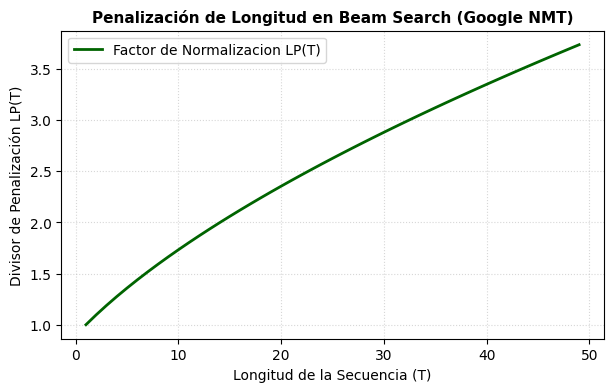

LP(1) = 1.00 | LP(10) = 1.73 | LP(30) = 2.88
✅ La penalización escala de forma sublineal impidiendo el sesgo contra secuencias largas


In [5]:
lengths = np.arange(1, 50)
alpha = 0.6
penalties = ((5.0 + lengths) ** alpha) / ((5.0 + 1.0) ** alpha)

plt.figure(figsize=(7, 4))
plt.plot(lengths, penalties, 'darkgreen', linewidth=2, label='Factor de Normalizacion LP(T)')
plt.title('Penalización de Longitud en Beam Search (Google NMT)', fontsize=11, fontweight='bold')
plt.xlabel('Longitud de la Secuencia (T)')
plt.ylabel('Divisor de Penalización LP(T)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

# Para T=1, LP(1) debe ser exactamente 1.0
assert np.isclose(penalties[0], 1.0)
print(f"LP(1) = {penalties[0]:.2f} | LP(10) = {penalties[9]:.2f} | LP(30) = {penalties[29]:.2f}")
print("✅ La penalización escala de forma sublineal impidiendo el sesgo contra secuencias largas")

### Reto 2 (Para resolver): Implementar Bucle de Auto-Corrección Reflexiva (Reflexion)
En el framework **Reflexion** (Shinn et al., 2023), si el resultado de una ejecución devuelve un error, el sistema genera una crítica analítica que se inyecta como contexto adicional para una segunda pasada de solución.

Implementa a continuación la función `reflective_agent_loop(problem_fn, max_tries=3)`:

In [6]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def reflective_agent_loop(problem_fn, max_tries: int = 3) -> Dict[str, Any]:
    """
    Ejecuta un bucle de auto-correccion reflexiva (Reflexion) ante fallos en evaluacion.
    """
    # Tu implementación aquí
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Wei, J., et al. (2022):** *"Chain-of-Thought Prompting Elicits Reasoning in Large Language Models"*, NeurIPS 2022. [arXiv:2201.11903](https://arxiv.org/abs/2201.11903)
   * *¿Qué leer?* Sección 3 ("Chain-of-Thought Prompting"): el nacimiento empírico de las cadenas de razonamiento.
2. **Wang, X., et al. (2022):** *"Self-Consistency Improves Chain of Thought Reasoning in Language Models"*, ICLR 2023. [arXiv:2203.11171](https://arxiv.org/abs/2203.11171)
   * *¿Qué leer?* La técnica de votación por consenso mayoritario sobre caminos estocásticos independientes.
3. **Yao, S., et al. (2023):** *"Tree of Thoughts: Deliberate Problem Solving with Large Language Models"*, NeurIPS 2023. [arXiv:2305.10601](https://arxiv.org/abs/2305.10601)
   * *¿Qué leer?* La formulación de resolución deliberativa de problemas usando búsqueda en árboles con backtracking.
4. **Snell, C., et al. (2024):** *"Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters"*, UC Berkeley. [arXiv:2408.03314](https://arxiv.org/abs/2408.03314)
   * *¿Qué leer?* El análisis teórico del cómputo en inferencia frente al cómputo de pre-entrenamiento.